# ch289 — KL Divergence

*(Directly extends ch288 — Entropy; appears in every generative model loss function)*

## 1. The Definition

The Kullback-Leibler divergence from $Q$ to $P$ measures how much information is lost when $Q$ is used to approximate $P$:

$$D_{KL}(P \| Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)} = E_P\left[\log \frac{P(X)}{Q(X)}\right]$$

Properties:
- $D_{KL}(P\|Q) \geq 0$ always (Gibbs' inequality)
- $D_{KL}(P\|Q) = 0$ iff $P = Q$ almost everywhere
- **Not symmetric**: $D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$ in general
- Not a distance metric (triangle inequality fails)

Connection to cross-entropy and entropy:
$$H(P, Q) = H(P) + D_{KL}(P \| Q)$$

Minimizing cross-entropy ↔ minimizing KL divergence (since $H(P)$ is fixed).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def kl_divergence_discrete(
    p: np.ndarray,
    q: np.ndarray,
    eps: float = 1e-15,
) -> float:
    """D_KL(P||Q) in nats. Assumes p,q sum to 1."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    mask = p > 0
    return np.sum(p[mask] * np.log(p[mask] / np.clip(q[mask], eps, 1.0)))


def entropy_discrete(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def cross_entropy_discrete(p: np.ndarray, q: np.ndarray) -> float:
    return entropy_discrete(p) + kl_divergence_discrete(p, q)


# Verify decomposition
p_true = np.array([0.5, 0.3, 0.2])
q_pred = np.array([0.3, 0.4, 0.3])

h_p    = entropy_discrete(p_true)
kl     = kl_divergence_discrete(p_true, q_pred)
ce     = cross_entropy_discrete(p_true, q_pred)
ce_dir = -np.sum(p_true * np.log(q_pred))

print(f"H(P):        {h_p:.6f}")
print(f"KL(P||Q):    {kl:.6f}")
print(f"H(P,Q):      {ce:.6f}")
print(f"Direct CE:   {ce_dir:.6f}")
print(f"H(P)+KL=CE:  {np.isclose(h_p + kl, ce)}")
print()
print(f"D_KL(P||Q) = {kl:.4f}")
print(f"D_KL(Q||P) = {kl_divergence_discrete(q_pred, p_true):.4f}  (asymmetric!)")

H(P):        1.029653
KL(P||Q):    0.088015
H(P,Q):      1.117668
Direct CE:   1.117668
H(P)+KL=CE:  True

D_KL(P||Q) = 0.0880
D_KL(Q||P) = 0.0835  (asymmetric!)


## 2. Forward vs Reverse KL

The asymmetry has practical consequences:

- **Forward KL** $D_{KL}(P\|Q)$: minimizing forces $Q$ to cover all modes of $P$ (zero-avoiding)
- **Reverse KL** $D_{KL}(Q\|P)$: minimizing forces $Q$ to concentrate on one mode of $P$ (mean-seeking)

This determines the behavior of variational inference methods.

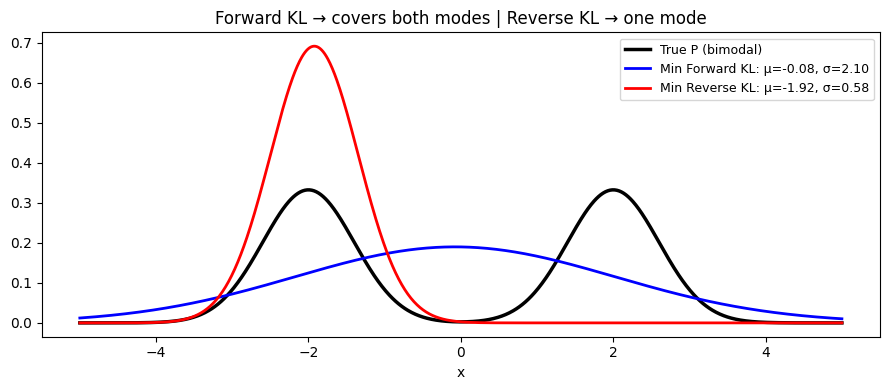

In [2]:
# Approximate a bimodal distribution with a Gaussian
# Forward KL: spread to cover both modes
# Reverse KL: collapse to one mode

x = np.linspace(-5, 5, 1000)
dx = x[1] - x[0]

# True distribution P: bimodal
p_true_cont = 0.5 * stats.norm.pdf(x, -2, 0.6) + 0.5 * stats.norm.pdf(x, 2, 0.6)
p_true_cont /= p_true_cont.sum() * dx  # normalize

# Search for Gaussian Q that minimizes forward vs reverse KL
def gaussian_pdf(x, mu, sigma):
    return stats.norm.pdf(x, mu, sigma)

def forward_kl(mu, sigma, p_true, x, dx):
    """D_KL(P||Q) for Gaussian Q."""
    q = gaussian_pdf(x, mu, sigma)
    q = np.clip(q, 1e-15, None)
    p = np.clip(p_true, 1e-15, None)
    return np.sum(p * np.log(p / q)) * dx

def reverse_kl(mu, sigma, p_true, x, dx):
    """D_KL(Q||P) for Gaussian Q."""
    q = gaussian_pdf(x, mu, sigma)
    q = np.clip(q, 1e-15, None)
    p = np.clip(p_true, 1e-15, None)
    return np.sum(q * np.log(q / p)) * dx

# Evaluate over a grid of (mu, sigma) and find minimizers
mus    = np.linspace(-3, 3, 40)
sigmas = np.linspace(0.3, 3.0, 40)

fwd_losses = np.array([
    [forward_kl(m, s, p_true_cont, x, dx) for s in sigmas] for m in mus
])
rev_losses = np.array([
    [reverse_kl(m, s, p_true_cont, x, dx) for s in sigmas] for m in mus
])

best_fwd = np.unravel_index(fwd_losses.argmin(), fwd_losses.shape)
best_rev = np.unravel_index(rev_losses.argmin(), rev_losses.shape)

mu_fwd, sig_fwd = mus[best_fwd[0]], sigmas[best_fwd[1]]
mu_rev, sig_rev = mus[best_rev[0]], sigmas[best_rev[1]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, p_true_cont, 'k-', lw=2.5, label='True P (bimodal)')
ax.plot(x, gaussian_pdf(x, mu_fwd, sig_fwd), 'b-', lw=2,
        label=f'Min Forward KL: μ={mu_fwd:.2f}, σ={sig_fwd:.2f}')
ax.plot(x, gaussian_pdf(x, mu_rev, sig_rev), 'r-', lw=2,
        label=f'Min Reverse KL: μ={mu_rev:.2f}, σ={sig_rev:.2f}')
ax.set_title('Forward KL → covers both modes | Reverse KL → one mode')
ax.set_xlabel('x'); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. What Comes Next

**ch290 — Mutual Information** combines entropy and KL divergence to measure how much two variables share. It is the non-linear, model-free generalization of correlation — applicable wherever Pearson's $r$ is not.